## Generating a random cube of ice based off initial MD-simulation
MD-simulation details:

The ice are melted at 400K under simulations at constant volume (so to keep density at 0.9400 cm^3/g). There is 128,000 mono-atomic water (they refer to this water model as they are modelling water molecule as one particle).
The simutlation time steps are 10 fs, ran for a total of 100,000 steps (so a total of 1,000,000 fs or 1 ns in simulation time). So the output frames are saved every 10,000 steps, leading to a total of 100 frames Frames 10 to 100 are considered steady state.

The goal of this notebook is to generate a binary 3D array (voxels are either 1s or 0s) which approximates the positions of amorphous ice molecules. The 3D FFT of this 3D array should yield the signature water ring at around 2.7~3 angstroms. The ice generation algorithm works as follows:
1. Obtain the average 3D FFT from the 90 frames of MD-simulated ice. The MD-simulation (due to cropping into a 3D box) has size of 100A x 100A x 100A, with pixel size of 0.5A (i.e. shape of 200px x 200px x 200px). The pixel size can be changed by resampling the raw MD-simulation data, but that is not available in this notebook due to the large size of the raw file.
2. State the desired size of ice cube (e.g. 200A in length, 0.5A => 400px x 400px x 400px). Based on this, we perform a cubic spline interpolation in Fourier space to obtain the desired 3D Fourier kernel. NOTE: the pixel size cannot be smaller than the original (default: 0.5A) as that would require extrapolation in Fourier space.
3. Initialize a new 3D binary array which represents the initial positions of ice molecules using random choice. This would have the correct number of ice molecules in the user-specified volume, but at incorrect positions.
4. Perform an iterative update which consists of:
   - 3D FFT the current ice volume
   - Multiply this Fourier volume with the ideal 3D ice Fourier kernel from step 2.
   - 3D IFFT, keep only amplitudes as we want a binary volume.
   - Use a 3D peak-finder to convert the real-space volume into a binary volume.
   - If the number of peaks (atoms) is less than the initial volume, then insert some 1s into this binary volume until the number of atoms is correct.
   - Repeat until no more changes happens to the volume. 

In [1]:
import matplotlib.pyplot as plt
import torch
from cryosim.icemaker import Icemaker
from cryosim.fft_tools import fft3

%load_ext autoreload
%autoreload 2

In [2]:
def plot3d(vol):
    fig, axes = plt.subplots(1, 3, dpi=200, constrained_layout=True)
    for i, ax in enumerate(axes.ravel()):
        im = ax.imshow(vol.sum(i))
        ax.set(xticks=[], yticks=[], title=f"projection along axis {i}")
        fig.colorbar(im, ax=ax, location="bottom")
    plt.show()


def plot_slices(
    vol, start_idx=0, end_idx=None, axis=0, ylabel=None, vmin=None, vmax=None
):
    nslices = 5
    sh = vol.shape
    if end_idx is None:
        idx_length = sh[axis] - start_idx - 1
        end_idx = start_idx + idx_length
    else:
        idx_length = end_idx - start_idx
    indices = torch.linspace(start_idx, end_idx, nslices).type(torch.int)

    fig, axes = plt.subplots(1, 5, dpi=200, figsize=(8, 2.8), constrained_layout=True)
    for ax, i in zip(axes.ravel(), indices):
        ax.set(xticks=[], yticks=[])
        if axis == 0:
            im = ax.imshow(vol[i, :, :], vmin=vmin, vmax=vmax)
        elif axis == 1:
            im = ax.imshow(vol[:, i, :], vmin=vmin, vmax=vmax)
        elif axis == 2:
            im = ax.imshow(vol[:, :, i], vmin=vmin, vmax=vmax)
        ax.set_title(f"Slice {i}")
        fig.colorbar(im, ax=ax, location="bottom")

    if ylabel is not None:
        axes[0].set_ylabel(ylabel)
    # plt.suptitle(f"Slices along axis {axis}")
    plt.show()

## Load averaged 3D Fourier kernel of ice (obtained from MD-simulations)

In [269]:
n = 200
dx = 0.66
icemake = Icemaker(n=n, dx=dx, min_distance=1.9)

In [270]:
icemake.correction_factor

2.9822154047360647

In [5]:
source = "torch"
filepath = "../ice-data/mdsim_f_radial_avg_400x400x400_0.25A.pt"

# source = 'dump'
# filepath = '/scratch/loh/joel/czii/stackingDisordered_20x20x20.MW_temp400.dump'

In [6]:
icemake.get_mdsim_f_radial_avg(saved_data_path=filepath)

(0.0, 2.0)

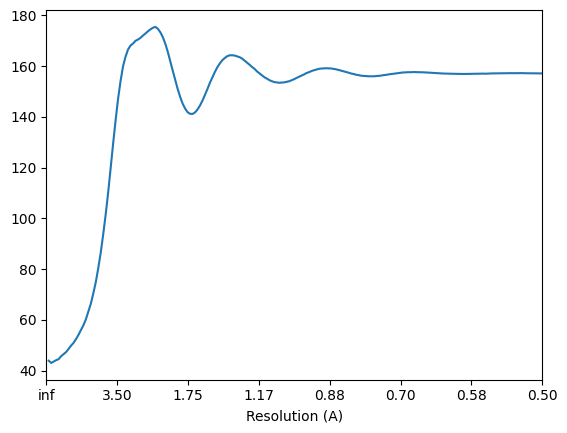

In [7]:
nticks = 8
maxk = 2
plt.plot(icemake.mdsim_radial_k[1:], icemake.mdsim_f_radial_avg[1:])
plt.xticks(
    torch.linspace(0, maxk, nticks),
    labels=[f"{1/k:.2f}" for k in torch.linspace(0, maxk, nticks)],
)
plt.xlabel("Resolution (A)")
plt.xlim([0, 2])

## Load Frame 100 of MD-simulation (can't upload all frames due to memory)

In [8]:
mdsim_frame100 = torch.load("../ice-data/mdsim_frame100_ice_deltas.pt")

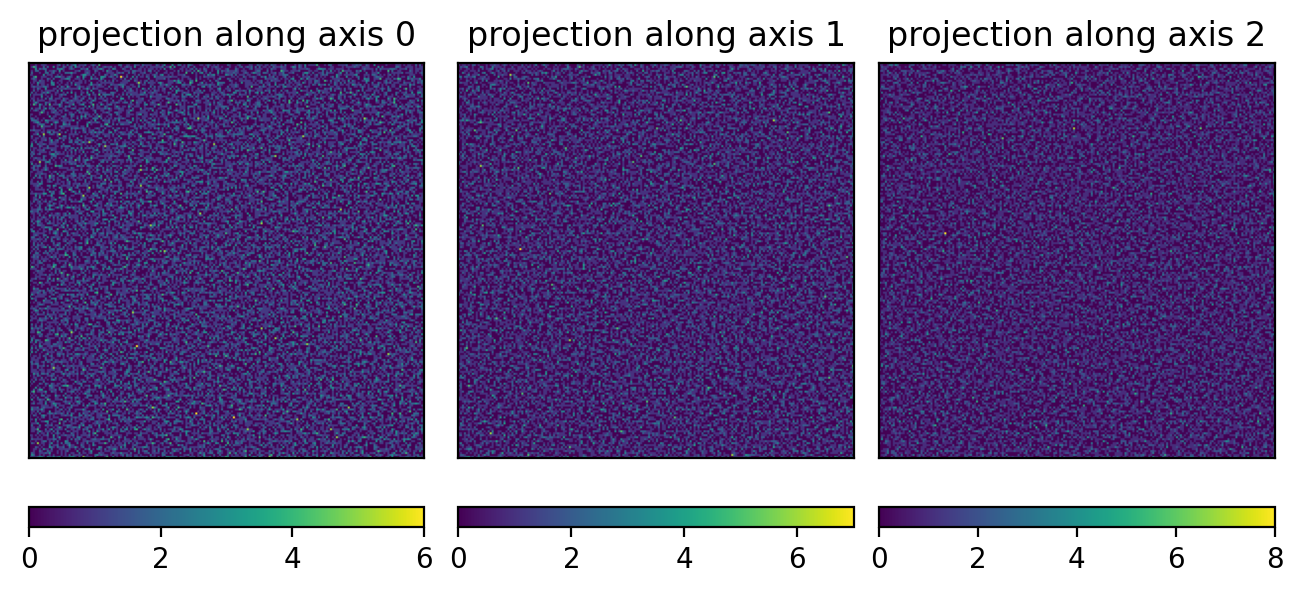

In [9]:
plot3d(mdsim_frame100)

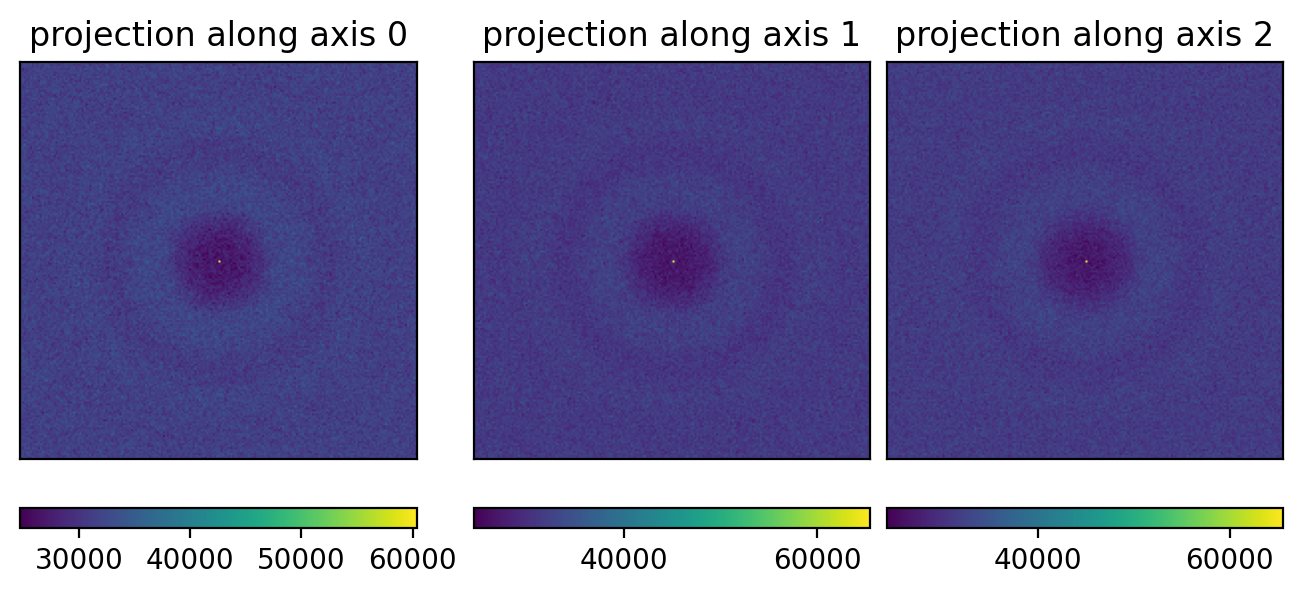

In [10]:
plot3d(torch.abs(fft3(mdsim_frame100)))

## Generate a new, random cube of ice
Must be larger than dx=0.5A

In [271]:
icemake.interpolate_mdsim_f_kernel()

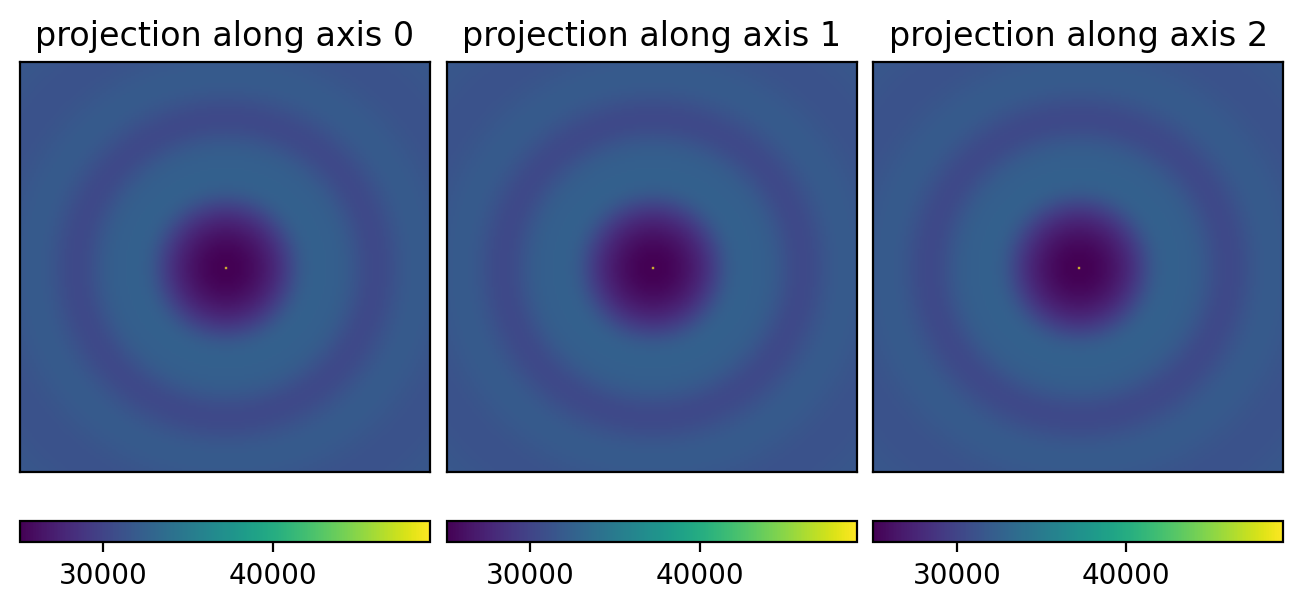

In [272]:
plot3d(icemake.interp_f_kernel)

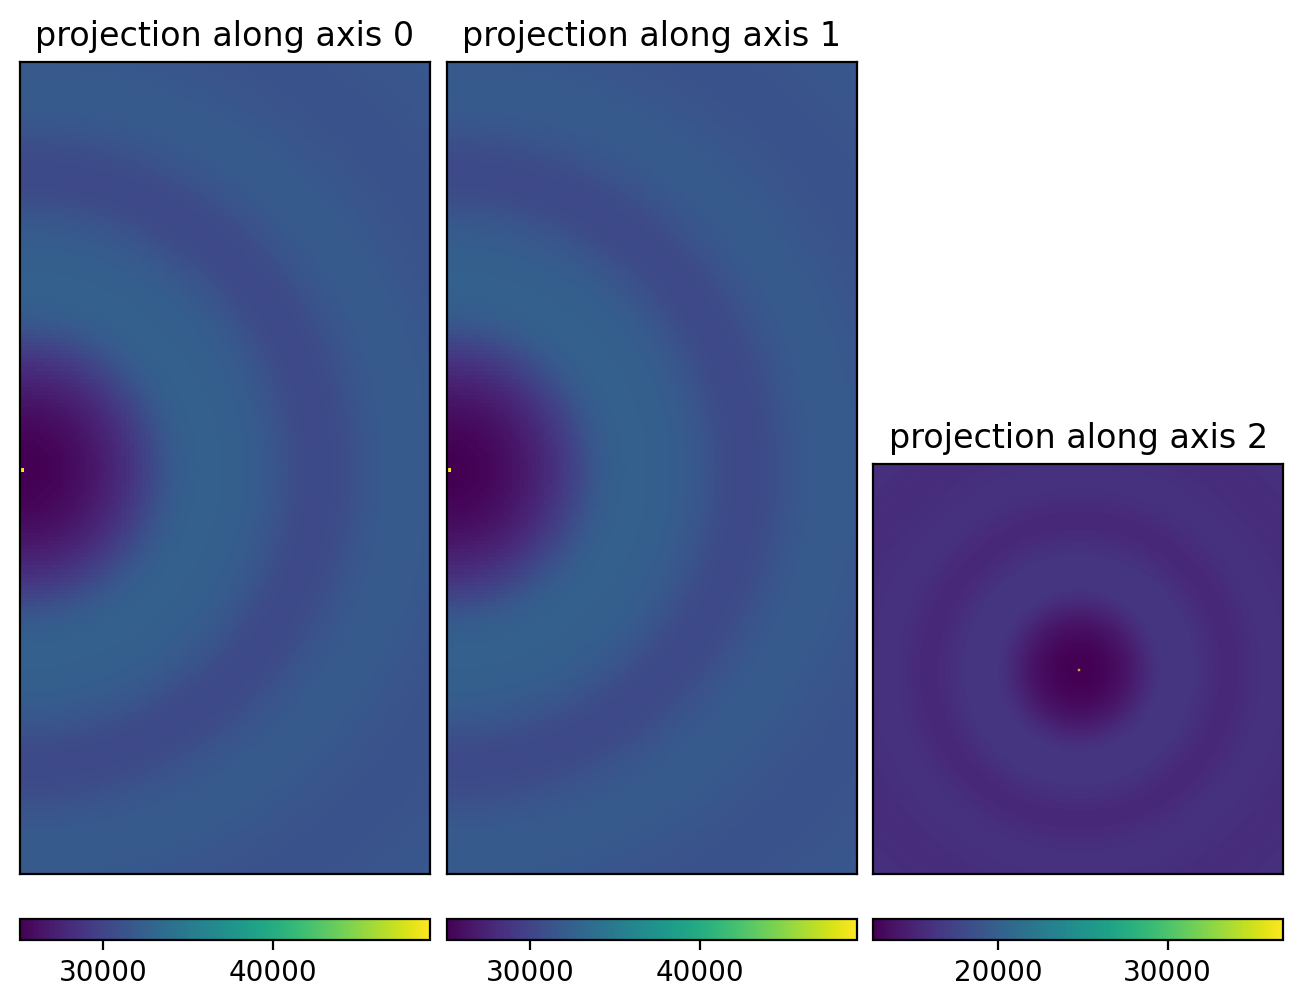

In [273]:
plot3d(icemake.interp_f_halfkernel)

In [274]:
init_ice_vol = icemake.create_initial_ice_volume()
icecubes = icemake.generate_ice()

Output()

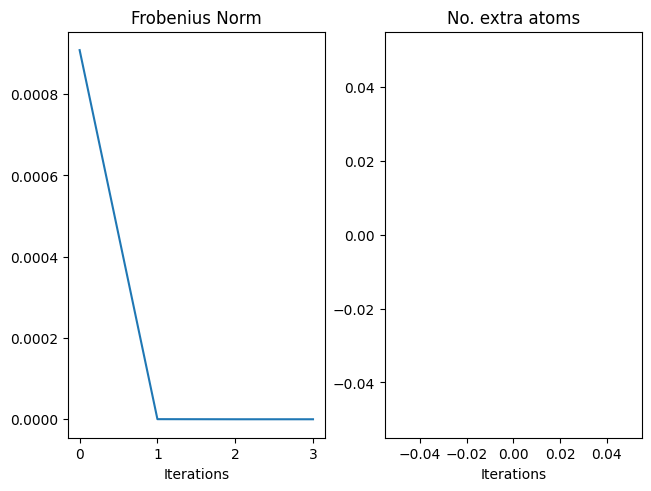

In [275]:
fig, axes = plt.subplots(1, 2, constrained_layout=True)
ax = axes[0]
ax.plot(icemake.frob_norm)
ax.set_title("Frobenius Norm")
ax.set_xlabel("Iterations")

ax = axes[1]
ax.plot(icemake.n_extra_atoms)
ax.set_title("No. extra atoms")
ax.set_xlabel("Iterations")
plt.show()

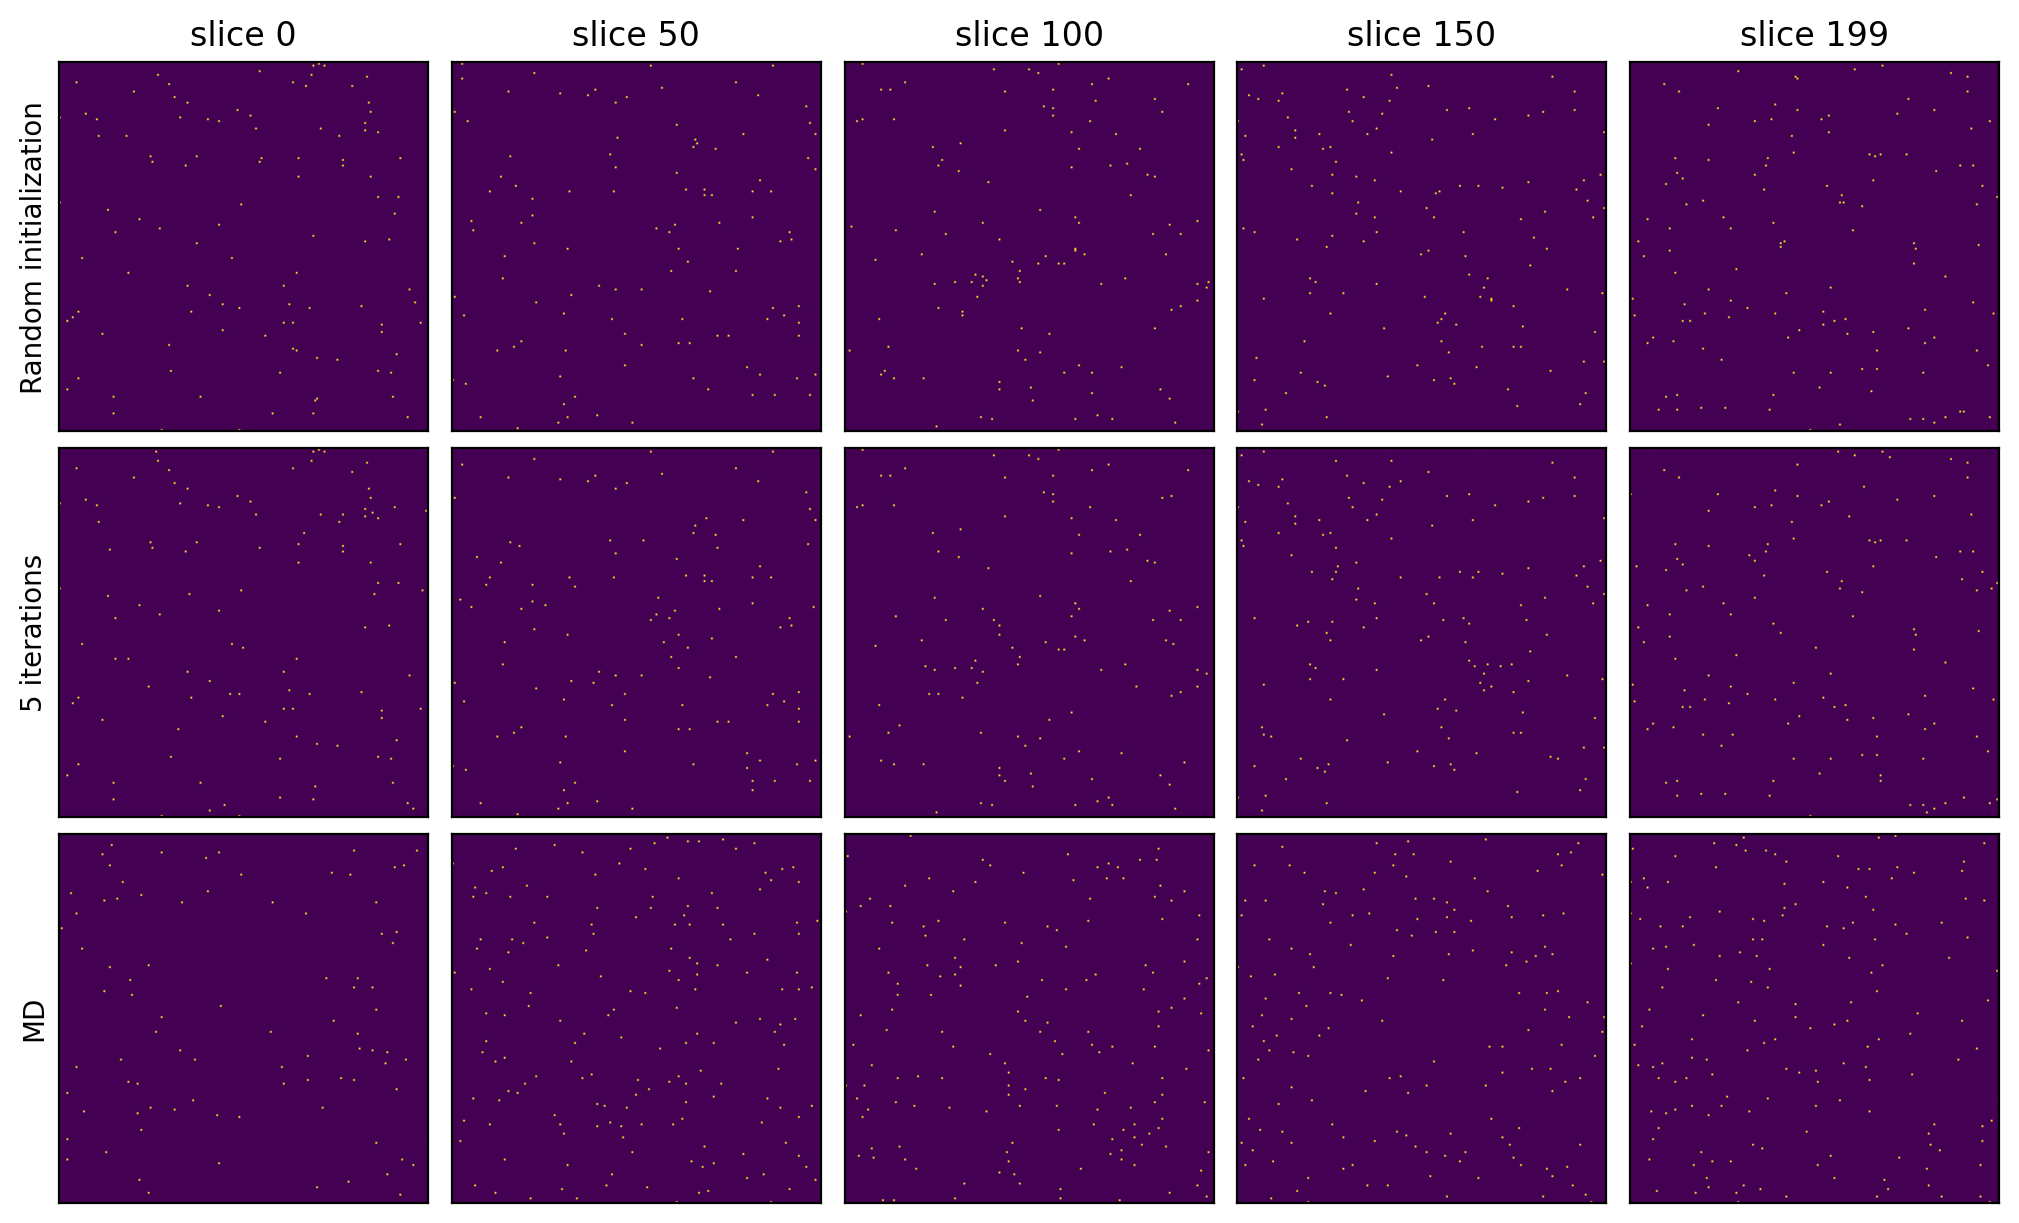

In [276]:
fig, axes = plt.subplots(3, 5, constrained_layout=True, figsize=(10, 6), dpi=200)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
for i in range(5):
    if i == 4:
        idx = n - 1
    else:
        idx = i * n // 4
    ax = axes[0, i]
    ax.imshow(icemake.ice_vol_init[0][idx])
    ax.set_title(f"slice {idx}")

    ax = axes[1, i]
    ax.imshow(icemake.current_icedeltas[0][idx])

    ax = axes[2, i]
    ax.imshow(mdsim_frame100[idx // 2])
axes[0, 0].set_ylabel("Random initialization")
axes[1, 0].set_ylabel(f"{icemake.niter} iterations")
axes[2, 0].set_ylabel("MD")
plt.show()

In [277]:
torch.sum(mdsim_frame100)

tensor(31401.)

In [278]:
icemake.n_ice_molecules

24233

In [279]:
torch.sum(icemake.current_icedeltas[0])

tensor(24233.)

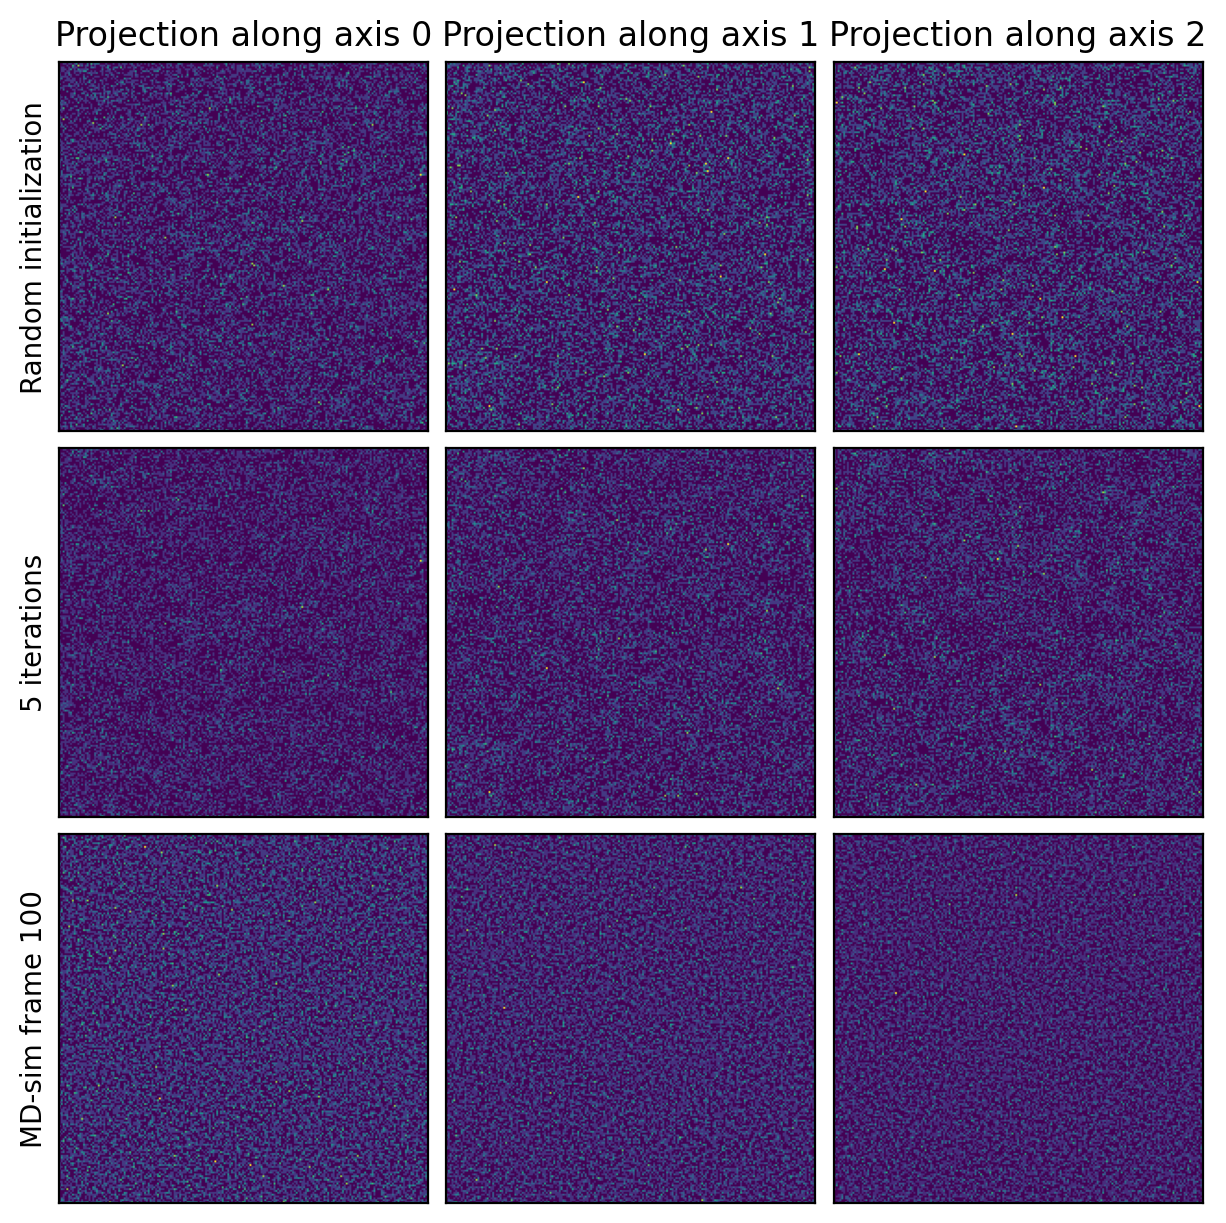

In [280]:
fig, axes = plt.subplots(3, 3, constrained_layout=True, figsize=(6, 6), dpi=200)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
for i in range(3):
    ax = axes[0, i]
    ax.imshow(icemake.ice_vol_init[0].sum(dim=i))
    ax.set_title(f"Projection along axis {i}")

    ax = axes[1, i]
    ax.imshow(icemake.current_icedeltas[0].sum(dim=i))

    ax = axes[2, i]
    ax.imshow(mdsim_frame100.sum(dim=i))

axes[0, 0].set_ylabel("Random initialization")
axes[1, 0].set_ylabel(f"{icemake.niter} iterations")
axes[2, 0].set_ylabel("MD-sim frame 100")
plt.show()

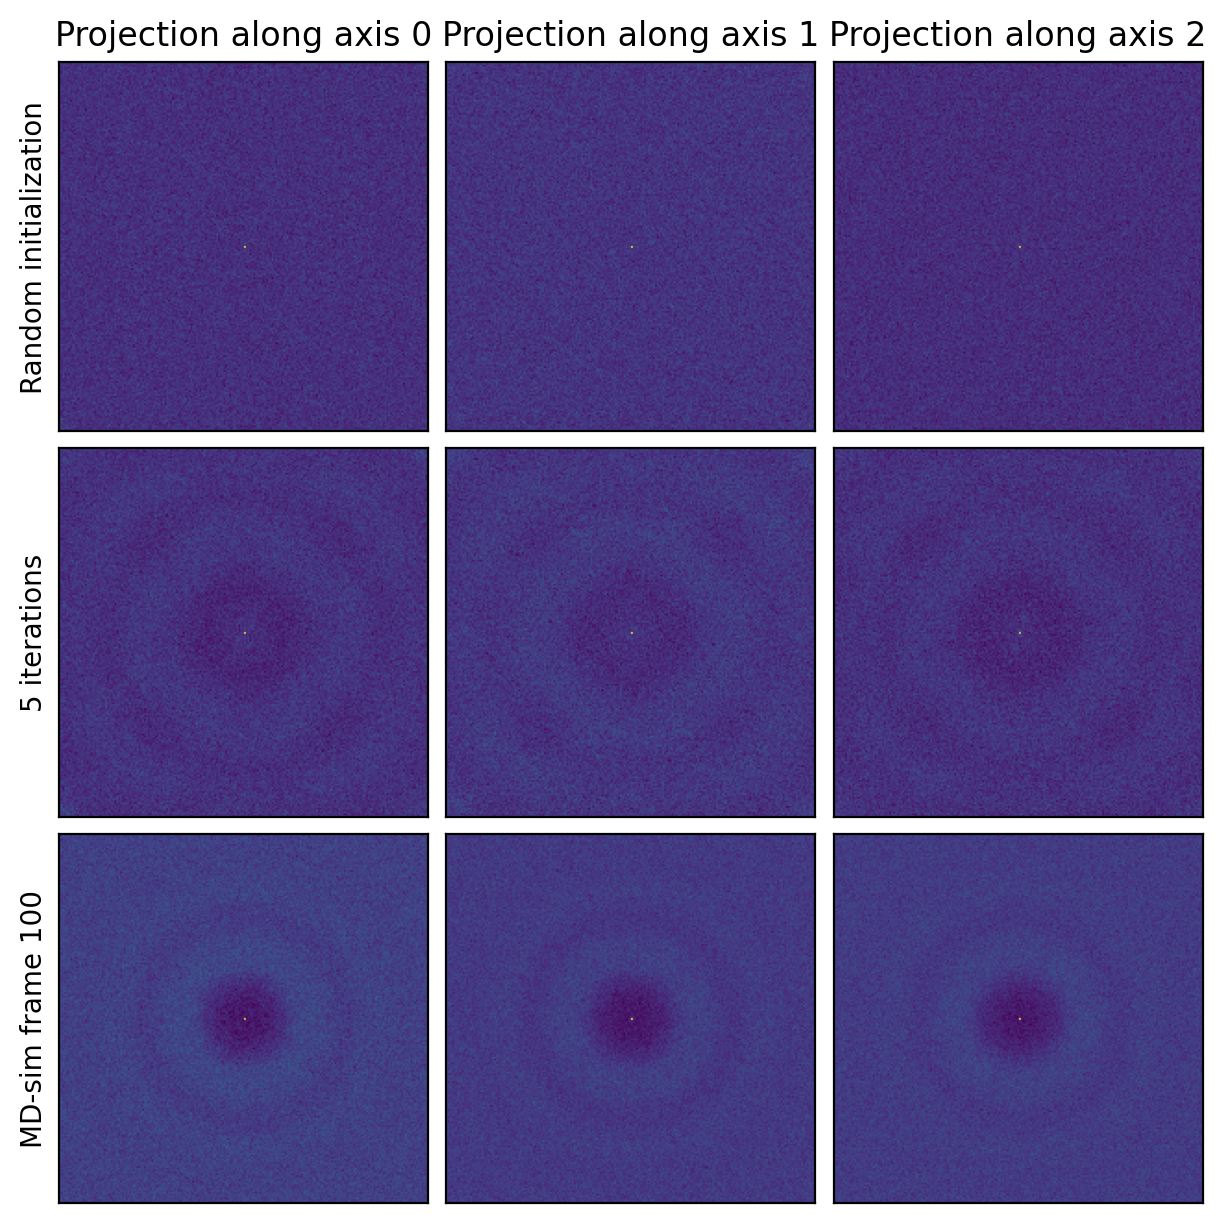

In [281]:
fig, axes = plt.subplots(3, 3, constrained_layout=True, figsize=(6, 6), dpi=200)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
for i in range(3):
    ax = axes[0, i]
    ax.imshow(torch.abs(fft3(icemake.ice_vol_init[0])).sum(dim=i))
    ax.set_title(f"Projection along axis {i}")

    ax = axes[1, i]
    ax.imshow(torch.abs(fft3(icemake.current_icedeltas[0])).sum(dim=i))

    ax = axes[2, i]
    ax.imshow(torch.abs(fft3(mdsim_frame100)).sum(dim=i))

axes[0, 0].set_ylabel("Random initialization")
axes[1, 0].set_ylabel(f"{icemake.niter} iterations")
axes[2, 0].set_ylabel("MD-sim frame 100")
plt.show()

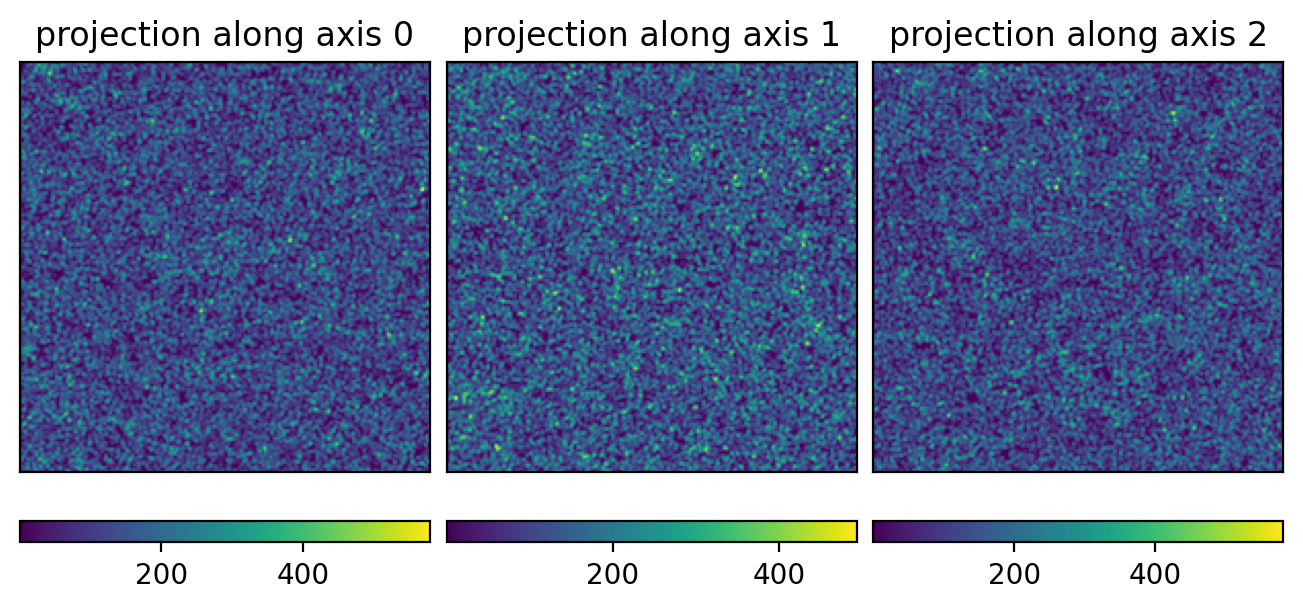

In [282]:
plot3d(icemake.icecubes[0])